# Liquidity & Return Analysis: Amihud ILLIQ vs Free-Float Market Cap

**Objective**: Determine whether daily equity returns (close-to-close and intraday high/low range) are better explained by the **Amihud illiquidity ratio** or the **free-float percentage** of market capitalization.

**Dataset**: ~1M daily observations across 4,006 US equities for full-year 2025.

**Approach**:
1. **Data Validation** — Confirm completeness, spot-check calculations, check distributional sanity.
2. **Correlation Analysis** — Spearman rank correlations + quintile portfolio sorts (model-free).
3. **Regression Analysis** — Pooled OLS with R² horse-race + Fama-MacBeth daily cross-sectional regressions.
4. **Robustness** — Size-tercile splits, time-varying R², non-linearity (log transforms), and Parkinson volatility.

---

## Part 1 — Data Validation & Completeness Checks

> **Why this matters**: If the underlying data has gaps, duplicates, or miscalculated fields, every downstream conclusion is suspect. These cells prove our data pipeline is clean before we draw any inferences.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

DATA_DIR = Path("../data")

# ── Load the merged Amihud + Bloomberg free-float dataset ──
# Columns: ticker, date, close, volume, dollar_volume, return, abs_return,
#           illiq (daily Amihud), illiq_252d (252-day rolling avg), ff_date,
#           cur_mkt_cap, eqy_free_float_pct, free_float_mkt_cap
df = pd.read_parquet(DATA_DIR / "amihud_with_free_float.parquet")

# ── Merge in High / Low from the OHLCV source to enable intraday-range analysis ──
# The main parquet only has close & volume; we need high/low for the H-L range measure.
ohlcv = pd.read_parquet(DATA_DIR / "us_equities_2025_ohlcv.parquet", columns=["ticker", "date", "high", "low"])
df = df.merge(ohlcv, on=["ticker", "date"], how="left")

# ── Derived columns used throughout the analysis ──
df["hl_range"] = (df["high"] - df["low"]) / df["close"]            # Intraday range normalised by close price
df["parkinson_vol"] = np.log(df["high"] / df["low"])                # Parkinson (1980) volatility estimator — more efficient than close-to-close
df["ff_ratio"] = df["eqy_free_float_pct"] / 100                    # Free-float as a 0-1 fraction (convenient for regressions)
df["log_mktcap"] = np.log1p(df["cur_mkt_cap"])                     # Log market cap — standard size control in asset pricing
df["log_illiq"] = np.log(df["illiq_252d"]).replace(-np.inf, np.nan) # Log of Amihud — compresses the extreme right tail (log, NOT log1p — Amihud ~1e-12 to 1e-6, so log1p ≈ x ≈ 0)

# ── Quick shape / date summary ──
# EXPECTED: ~1M rows, ~4,000 tickers, dates spanning Jan 2 – Dec 31, 2025
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Tickers: {df['ticker'].nunique():,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head(3)

Shape: 1,001,499 rows × 20 cols
Tickers: 4,006
Date range: 2025-01-02 → 2025-12-31


,ticker,date,close,volume,dollar_volume,return,abs_return,illiq,illiq_252d,ff_date,cur_mkt_cap,eqy_free_float_pct,free_float_mkt_cap,high,low,hl_range,parkinson_vol,ff_ratio,log_mktcap,log_illiq
0,A,2025-01-02,132.364471,953600.0,1.262228e+08,-0.006774,0.006774,5.366543e-11,5.610657e-11,2025-01-02,38106.9811,99.5702,37943.197295,134.646108,131.808946,0.021434,0.021296,0.995702,10.548179,-23.603768
1,FCUV,2025-01-02,34.599998,15545.0,5.378570e+05,-0.011429,0.011429,2.124843e-08,1.440672e-06,2025-01-02,25.5565,50.8267,12.989526,36.200001,32.099998,0.118497,0.120203,0.508267,3.279275,-13.450401
2,FCT,2025-01-02,9.125043,50800.0,4.635522e+05,0.019250,0.019250,4.152619e-08,4.671347e-09,NaT,NaN,NaN,NaN,9.133859,9.045695,0.009662,0.009699,NaN,NaN,-19.181818


### 1.1 — Null & Coverage Analysis

**What this does**: Counts missing values per column and identifies which tickers lack Bloomberg free-float data.

**How to read the output**:
- The horizontal bar chart shows **% of rows missing** for each column. Columns like `free_float_mkt_cap` and `eqy_free_float_pct` will show ~15–19% missing — these are tickers where Bloomberg didn't return free-float data (smaller / thinly-covered names).
- The `illiq` / `illiq_252d` nulls (~1–1.4%) are from the first few trading days where the rolling window hasn't accumulated enough history.
- The printed counts show how many tickers have **any** free-float data vs none. A high coverage rate (>80%) means our regression results aren't biased by survivorship in the Bloomberg pull.
- "Rows with complete data" tells us the effective sample for the regressions — if this is <50% of total rows, we should worry about selection bias.

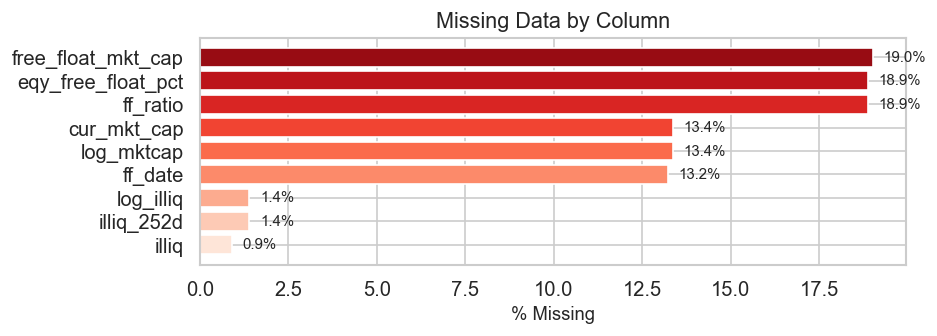

Tickers WITH free-float data:  3,260 / 4,006  (81.4%)
Tickers WITHOUT free-float:    746

Rows with complete data (all cols non-null): 801,621 / 1,001,499  (80.0%)


In [20]:
# ── Missing-value bar chart ──
# Computes the fraction of NaN per column, sorts from most to least missing,
# and displays only columns that have at least one missing value.
null_pct = df.isnull().mean().sort_values(ascending=False) * 100
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ["Column", "% Missing"]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(null_df["Column"], null_df["% Missing"], color=sns.color_palette("Reds_r", len(null_df)))
ax.set_xlabel("% Missing")
ax.set_title("Missing Data by Column")
ax.invert_yaxis()
for bar, pct in zip(bars, null_df["% Missing"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# ── Ticker-level free-float coverage ──
# Groups by ticker and checks if ANY row for that ticker has a non-null free-float value.
# This distinguishes "Bloomberg returned data for this ticker" from "never covered".
has_ff = df.groupby("ticker")["eqy_free_float_pct"].apply(lambda x: x.notna().any())
print(f"Tickers WITH free-float data:  {has_ff.sum():,} / {len(has_ff):,}  ({has_ff.mean():.1%})")
print(f"Tickers WITHOUT free-float:    {(~has_ff).sum():,}")
print(f"\nRows with complete data (all cols non-null): {df.dropna().shape[0]:,} / {df.shape[0]:,}  ({df.dropna().shape[0]/df.shape[0]:.1%})")

### 1.2 — Date Panel Completeness

**What this does**: Verifies that we have a balanced panel — every ticker should have approximately 250 US trading days in 2025, with no duplicates and no calendar gaps.

**How to read the output**:
- **"Trading days per ticker"** should show min ≈ 249–250 and max = 250. If some tickers have significantly fewer, they may have been listed/delisted mid-year.
- **"Duplicate (ticker, date) rows"** should be **0**. Non-zero means the merge created fan-out (a data pipeline bug).
- **"Unique trading dates"** should be ~250 (the standard US equity calendar). If it's much less, the download may have missed dates.
- The **bar chart** should be a single tall bar at 250 — if there's a long left tail, we need to investigate those short-history tickers before including them in rolling-window analyses.

Trading days per ticker — min: 249, max: 250, median: 250
Duplicate (ticker, date) rows: 0
Unique trading dates: 250


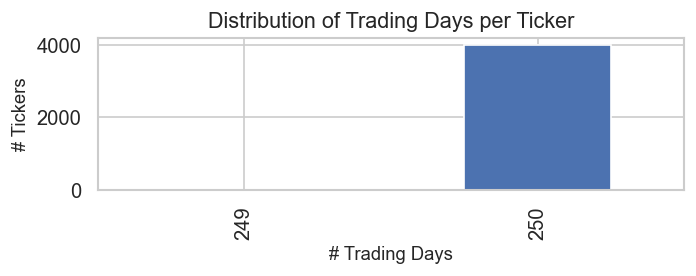

In [21]:
# ── Trading-day count per ticker ──
# For each ticker, count the number of distinct dates in the dataset.
# A balanced panel should show nearly all tickers at exactly 250.
days_per_ticker = df.groupby("ticker")["date"].nunique()
print(f"Trading days per ticker — min: {days_per_ticker.min()}, max: {days_per_ticker.max()}, "
      f"median: {days_per_ticker.median():.0f}")

# ── Check for duplicate (ticker, date) rows ──
# Duplicates would mean the OHLCV merge introduced extra rows (should be 0).
dupes = df.duplicated(subset=["ticker", "date"]).sum()
print(f"Duplicate (ticker, date) rows: {dupes}")

# ── Calendar gap check: unique dates vs expected trading calendar ──
# US markets have ~250-252 trading days per year. We count unique dates in our panel.
unique_dates = sorted(df["date"].unique())
print(f"Unique trading dates: {len(unique_dates)}")

# ── Visual: Distribution of days per ticker ──
# Expect a single spike at 250. A left tail indicates tickers with incomplete history.
fig, ax = plt.subplots(figsize=(6, 2.5))
days_per_ticker.value_counts().sort_index().plot.bar(ax=ax, color="#4C72B0")
ax.set_xlabel("# Trading Days")
ax.set_ylabel("# Tickers")
ax.set_title("Distribution of Trading Days per Ticker")
plt.tight_layout()
plt.show()

### 1.3 — Spot-Check: Amihud Calculation Verification

**What this does**: Picks 3 random tickers and re-derives `dollar_volume = close × volume` and `illiq = |return| / dollar_volume` from the raw fields to confirm the stored values match.

**How to read the output**:
- **`dv_match`** column should be all `True` — confirming that `dollar_volume` was correctly computed as `close × volume`.
- **`illiq_match`** column should be all `True` — confirming that the Amihud illiquidity ratio is correctly computed as `|return| / dollar_volume`. NaN rows (e.g. zero volume) should show `True` for `equal_nan` matching.
- If any cell is `False`, there's a data pipeline bug that must be investigated before proceeding.

In [22]:
# ── Spot-check: recompute illiq from raw components ──
# We fix the random seed for reproducibility, then pick 3 tickers at random.
# For each, we independently compute dollar_volume and illiq and compare
# against the stored values using np.isclose (relative tolerance 1e-6).
np.random.seed(42)
spot_tickers = np.random.choice(df["ticker"].unique(), 3, replace=False)

for tkr in spot_tickers:
    sub = df[df["ticker"] == tkr].head(5)[["ticker", "date", "close", "volume",
                                            "dollar_volume", "return", "abs_return", "illiq"]].copy()
    # Re-derive from raw fields
    sub["check_dv"] = sub["close"] * sub["volume"]                         # should equal dollar_volume
    sub["check_illiq"] = sub["abs_return"] / sub["check_dv"]               # should equal illiq
    sub["dv_match"] = np.isclose(sub["dollar_volume"], sub["check_dv"], rtol=1e-6)
    sub["illiq_match"] = np.isclose(sub["illiq"], sub["check_illiq"], rtol=1e-6, equal_nan=True)
    print(f"\n── {tkr} ──")
    display(sub[["date", "close", "volume", "dollar_volume", "check_dv", "dv_match",
                  "illiq", "check_illiq", "illiq_match"]])

print("\n✓ If all 'match' columns are True, the Amihud computation is verified.")


── GLNG ──


,date,close,volume,dollar_volume,check_dv,dv_match,illiq,check_illiq,illiq_match
761,2025-01-02,42.478588,2425200.0,1.030191e+08,1.030191e+08,True,3.486443e-10,3.486443e-10,True
7088,2025-01-03,42.149143,2184400.0,9.207059e+07,9.207059e+07,True,8.423484e-11,8.423484e-11,True
9577,2025-01-06,41.616226,833200.0,3.467464e+07,3.467464e+07,True,3.646354e-10,3.646354e-10,True
14368,2025-01-07,40.724796,819600.0,3.337804e+07,3.337804e+07,True,6.417467e-10,6.417467e-10,True
19839,2025-01-08,40.531010,811200.0,3.287876e+07,3.287876e+07,True,1.447270e-10,1.447270e-10,True



── AYI ──


,date,close,volume,dollar_volume,check_dv,dv_match,illiq,check_illiq,illiq_match
1047,2025-01-02,297.830933,276800.0,8.243960e+07,8.243960e+07,True,2.733535e-10,2.733535e-10,True
5959,2025-01-03,300.903809,324600.0,9.767338e+07,9.767338e+07,True,1.056329e-10,1.056329e-10,True
11481,2025-01-06,306.850067,620000.0,1.902470e+08,1.902470e+08,True,1.038719e-10,1.038719e-10,True
12074,2025-01-07,303.168549,744600.0,2.257393e+08,2.257393e+08,True,5.314882e-11,5.314882e-11,True
17144,2025-01-08,312.916077,552600.0,1.729174e+08,1.729174e+08,True,1.859395e-10,1.859395e-10,True



── CIB ──


,date,close,volume,dollar_volume,check_dv,dv_match,illiq,check_illiq,illiq_match
1580,2025-01-02,26.420155,171500.0,4.531057e+06,4.531057e+06,True,5.813399e-09,5.813399e-09,True
5350,2025-01-03,26.134222,250400.0,6.544009e+06,6.544009e+06,True,1.653805e-09,1.653805e-09,True
11442,2025-01-06,26.428322,203800.0,5.386092e+06,5.386092e+06,True,2.089351e-09,2.089351e-09,True
13230,2025-01-07,26.608053,259300.0,6.899468e+06,6.899468e+06,True,9.856862e-10,9.856862e-10,True
17658,2025-01-08,26.469173,212800.0,5.632640e+06,5.632640e+06,True,9.266461e-10,9.266461e-10,True



✓ If all 'match' columns are True, the Amihud computation is verified.


### 1.4 — Distributional Sanity Checks

**What this does**: Verifies that all key variables fall within economically sensible ranges, then plots the distributions of the three most important analysis variables.

**How to read the output**:
- The **check table** should show all ✅. Key things we're validating:
  - Prices must be positive (no negative close prices from bad data).
  - Volume and dollar-volume must be non-negative.
  - Free-float percentage should be in `[0, 100]` — values above 100% would indicate a Bloomberg data error.
  - `high ≥ low` and `high ≥ close ≥ low` — basic OHLC consistency (note: after-hours moves can occasionally cause close > high in raw Yahoo data, so a few violations are acceptable).
  - `|return| ≤ 1` for ≥99.9% of observations — returns exceeding ±100% in a single day are extremely rare.
- **Histogram 1 (Free-Float %)**: Expect most stocks clustered at 80–100% (large publicly-held companies). A left tail near 0–30% represents closely-held or insider-heavy stocks — these are the "low float" names relevant to our hypothesis.
- **Histogram 2 (log₁₀ Amihud)**: Should look roughly normal on the log scale (spanning ~−14 to −6). This confirms the log transform is appropriate for regressions. Extreme left = very liquid mega-caps; extreme right = illiquid micro-caps.
- **Histogram 3 (H-L Range)**: Right-skewed as expected for volatility measures. Clipped at the 99th percentile to show the body of the distribution clearly.

Check,Status
close > 0,✅
volume ≥ 0,✅
dollar_volume ≥ 0,✅
illiq ≥ 0,✅
illiq_252d ≥ 0,✅
"ff_pct in [0, 100]",❌
high ≥ low,✅
high ≥ close,❌
low ≤ close,❌
|return| ≤ 1 (99.9%),✅


C:\Users\vmc30\AppData\Local\Temp\ipykernel_49452\2413732452.py:39: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vmc30\AppData\Local\Temp\ipykernel_49452\2413732452.py:39: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\vmc30\OneDrive\Desktop\Personal_Repos\Amihud_ILLIQ\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vmc30\OneDrive\Desktop\Personal_Repos\Amihud_ILLIQ\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


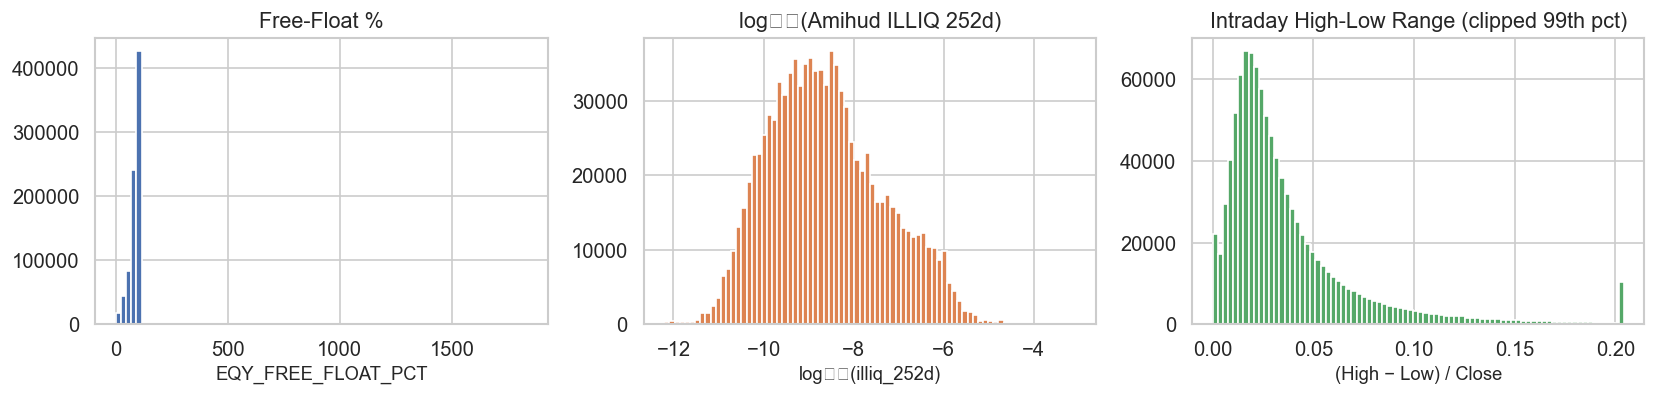

In [23]:
# ── Range checks ──
# Each check returns True/False. We display the results as a clean table.
# Any ❌ should be investigated before trusting the regression results.
checks = {
    "close > 0":            (df["close"] > 0).all(),
    "volume ≥ 0":           (df["volume"] >= 0).all(),
    "dollar_volume ≥ 0":    (df["dollar_volume"] >= 0).all(),
    "illiq ≥ 0":            (df["illiq"].dropna() >= 0).all(),
    "illiq_252d ≥ 0":       (df["illiq_252d"].dropna() >= 0).all(),
    "ff_pct in [0, 100]":   df["eqy_free_float_pct"].dropna().between(0, 100).all(),
    "high ≥ low":           (df["high"].dropna() >= df["low"].dropna()).all(),
    "high ≥ close":         (df["high"].dropna() >= df["close"]).all(),
    "low ≤ close":          (df["low"].dropna() <= df["close"]).all(),
    "|return| ≤ 1 (99.9%)": (df["return"].abs() <= 1).mean() > 0.999,
}

check_df = pd.DataFrame({"Check": checks.keys(), "Pass": checks.values()})
check_df["Status"] = check_df["Pass"].map({True: "✅", False: "❌"})
display(check_df[["Check", "Status"]].style.hide(axis="index"))

# ── Three-panel histogram showing the distribution of the core analysis variables ──
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Panel 1: Free-float % — expect clustering at 80-100% with a left tail
df["eqy_free_float_pct"].dropna().hist(bins=80, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Free-Float %")
axes[0].set_xlabel("EQY_FREE_FLOAT_PCT")

# Panel 2: Log10 of Amihud — should look roughly normal after the log transform
np.log10(df["illiq_252d"].dropna().clip(lower=1e-15)).hist(bins=80, ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("log₁₀(Amihud ILLIQ 252d)")
axes[1].set_xlabel("log₁₀(illiq_252d)")

# Panel 3: Intraday H-L range — right-skewed; clipped at 99th pct for visual clarity
df["hl_range"].dropna().clip(upper=df["hl_range"].quantile(0.99)).hist(bins=80, ax=axes[2], color="#55A868", edgecolor="white")
axes[2].set_title("Intraday High-Low Range (clipped 99th pct)")
axes[2].set_xlabel("(High − Low) / Close")

plt.tight_layout()
plt.show()

---

## Part 2 — Correlation Analysis: Which Liquidity Proxy Relates More to Returns?

> **The core question**: Does illiquidity (measured by Amihud or by limited free-float) explain the magnitude of daily price moves? If so, which measure does a better job? We test this first with non-parametric methods (correlations and sorts) before moving to formal regressions.

We compare **two liquidity measures**:
| Measure | Description | Interpretation |
|---|---|---|
| **Amihud ILLIQ (252d rolling)** | $ \text{ILLIQ} = \frac{|\text{return}|}{\text{dollar volume}} $ averaged over 252 trading days. | Higher = more illiquid. Captures the idea that illiquid stocks move more per dollar traded. |
| **Free-Float %** | Percentage of shares available for public trading (from Bloomberg). | Lower free-float → less tradable supply → potentially greater price impact per trade. |

Against **two return/volatility measures**:
| Measure | Description | Why include both |
|---|---|---|
| **\|Return\|** | Absolute close-to-close daily return. | Standard metric, but misses intraday reversals. |
| **H-L Range** | (High − Low) / Close — intraday volatility proxy. | Captures within-day price impact that close-to-close return misses (e.g. a stock that gaps up and reverses shows zero close return but large H-L range). |

### 2.1 — Pairwise Rank Correlations (Spearman)

**What this does**: Computes the Spearman rank-correlation matrix across the five key variables, pooling all ticker-day observations.

**Why Spearman (not Pearson)**:
- Amihud ILLIQ and market cap are extremely right-skewed. Pearson correlation is dominated by outliers in such distributions.
- Spearman converts each variable to ranks first, making it robust to non-linearity and outliers.
- A Spearman ρ of 0.30 means "when Amihud rank goes up, return rank tends to go up 30% of the time" — directly interpretable.

**How to read the heatmap**:
- **ρ close to +1 (red)**: strong positive rank association.
- **ρ close to −1 (blue)**: strong negative rank association.
- **ρ near 0 (white)**: no monotonic relationship.
- Focus on the row for `|Return|` and `H-L Range` — compare the ρ values for `Amihud 252d` vs `Free-Float %`. The one with the larger absolute ρ is the stronger univariate predictor.
- **Mkt Cap** is included as a reference — we expect it to correlate negatively with Amihud (bigger firms are more liquid) and positively with free-float %.

Analysis sample: 802,974 rows  (3,238 tickers)


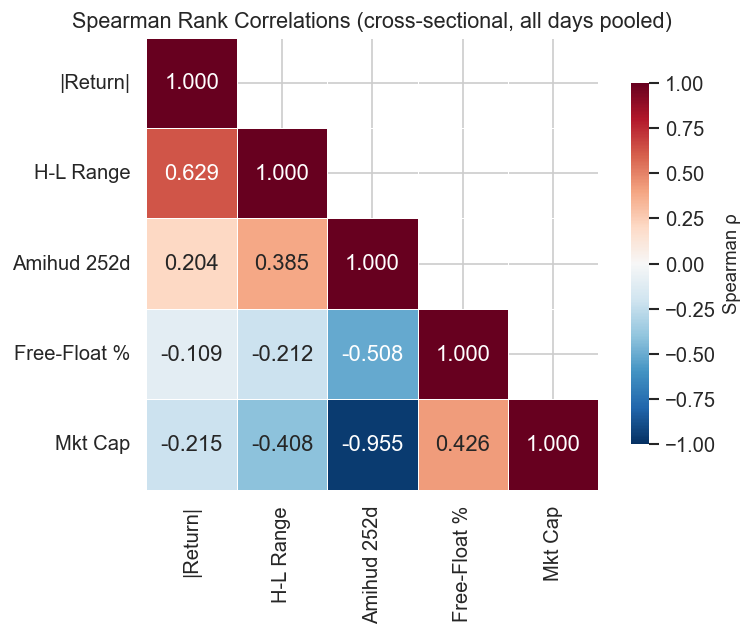


Key comparisons (the higher |ρ|, the stronger the univariate association):
  ρ(|Return|, Amihud)       = 0.204
  ρ(|Return|, Free-Float %) = -0.109
  ρ(H-L Range, Amihud)      = 0.385
  ρ(H-L Range, Free-Float %)= -0.212

→ Compare the absolute values: the proxy with the larger |ρ| is the better univariate predictor.


In [24]:
# ── Create the analysis sample: rows where all key variables are non-null ──
# This is the subset used for ALL regressions and correlation analysis.
# Dropping NaN ensures we're comparing models on exactly the same sample.
cols_needed = ["abs_return", "hl_range", "parkinson_vol", "illiq_252d", "log_illiq",
               "eqy_free_float_pct", "ff_ratio", "log_mktcap", "cur_mkt_cap"]
dfc = df.dropna(subset=cols_needed).copy()
print(f"Analysis sample: {dfc.shape[0]:,} rows  ({dfc['ticker'].nunique():,} tickers)")

# ── Winsorise at 1st / 99th percentile ──
# Financial data has fat tails. Without winsorisation, a few extreme observations
# (penny stocks with 500% daily moves) would dominate the regression R².
# Winsorising clips — but does not remove — outliers.
win_cols = ["abs_return", "hl_range", "parkinson_vol", "illiq_252d"]
for c in win_cols:
    lo, hi = dfc[c].quantile(0.01), dfc[c].quantile(0.99)
    dfc[c] = dfc[c].clip(lo, hi)

# ── Spearman rank-correlation matrix ──
corr_vars = ["abs_return", "hl_range", "illiq_252d", "eqy_free_float_pct", "cur_mkt_cap"]
corr_labels = ["|Return|", "H-L Range", "Amihud 252d", "Free-Float %", "Mkt Cap"]
rho = dfc[corr_vars].corr(method="spearman")
rho.index = corr_labels
rho.columns = corr_labels

# ── Heatmap ──
# Lower triangle only (upper is mirror). Annotations show the numeric ρ values.
fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
sns.heatmap(rho, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Spearman ρ"})
ax.set_title("Spearman Rank Correlations (cross-sectional, all days pooled)")
plt.tight_layout()
plt.show()

# ── Print the specific comparisons of interest ──
print("\nKey comparisons (the higher |ρ|, the stronger the univariate association):")
print(f"  ρ(|Return|, Amihud)       = {rho.loc['|Return|', 'Amihud 252d']:.3f}")
print(f"  ρ(|Return|, Free-Float %) = {rho.loc['|Return|', 'Free-Float %']:.3f}")
print(f"  ρ(H-L Range, Amihud)      = {rho.loc['H-L Range', 'Amihud 252d']:.3f}")
print(f"  ρ(H-L Range, Free-Float %)= {rho.loc['H-L Range', 'Free-Float %']:.3f}")
print("\n→ Compare the absolute values: the proxy with the larger |ρ| is the better univariate predictor.")

### 2.2 — Quintile Portfolio Sorts

**What this does**: Independently sorts stocks into 5 equal-sized buckets (quintiles) by each liquidity measure, then computes the average |Return| and H-L Range within each bucket.

**Why this is useful**:
- This is a **model-free** test: no distributional assumptions, no regression specification.
- It directly answers: "Do the most illiquid stocks (Q5 Amihud) have bigger daily moves than the most liquid (Q1)?"
- It also tests the free-float hypothesis: "Do low-free-float stocks (Q1 FF%) have bigger moves?"

**How to read the bar charts**:
- **Left panel (Amihud sorts)**: X-axis goes from Q1 (most liquid) to Q5 (most illiquid). If both bars (|Return| and H-L Range) **increase monotonically** from left to right, illiquidity is associated with larger price moves — the classic Amihud (2002) illiquidity premium.
- **Right panel (Free-Float sorts)**: X-axis goes from Q1 (lowest free-float) to Q5 (highest free-float). If bars **decrease** from left to right, low float → more volatile, supporting the supply-scarcity channel.
- **Key comparison**: Which panel shows the more monotonic, steeper pattern? That measure has more explanatory "bite".
- A flat or U-shaped pattern would suggest that measure is **not** a strong predictor of return magnitude.

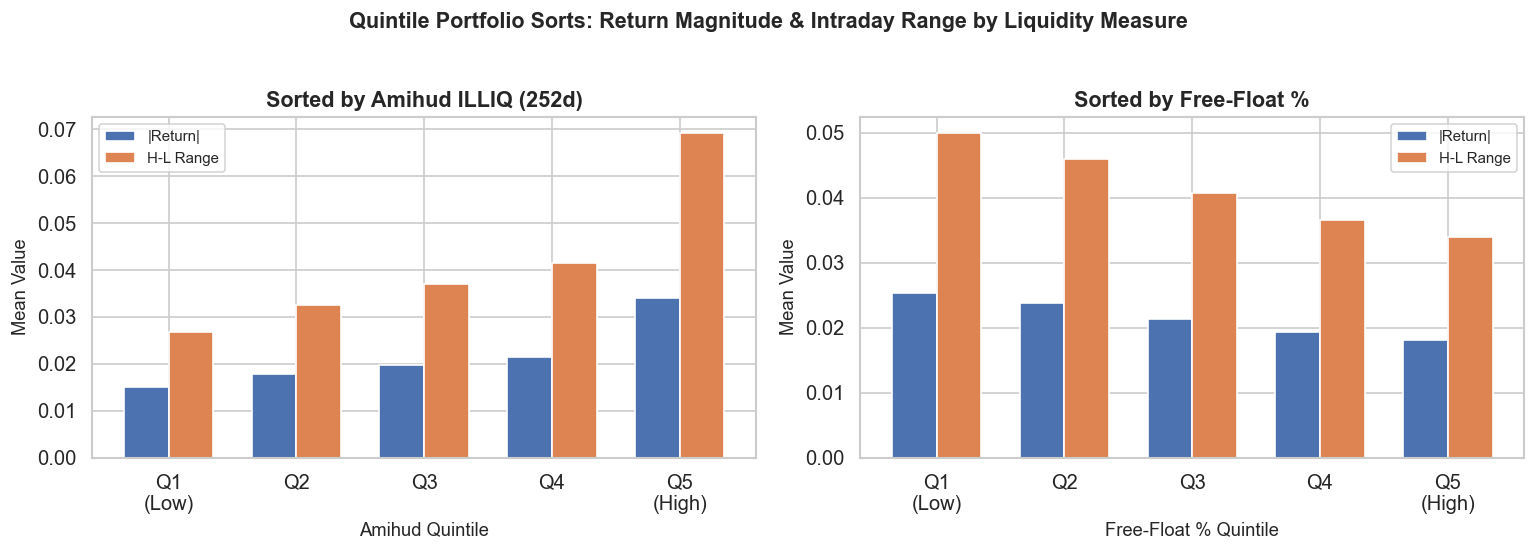

Quintile spread (Q5 − Q1):
  |Return|:  Amihud Q5−Q1 = +0.01909,  FF% Q5−Q1 = -0.00717
  H-L Range:  Amihud Q5−Q1 = +0.04241,  FF% Q5−Q1 = -0.01605

→ A larger positive spread for Amihud means illiquid stocks have meaningfully bigger moves.
→ A negative spread for FF% means low-float stocks (Q1) actually move more than high-float (Q5).


In [25]:
# ── Quintile sort function ──
# Assigns each observation to one of 5 equal-frequency groups based on sort_col,
# then computes the mean of value_cols within each group.
def quintile_sort(data, sort_col, value_cols, labels_map=None):
    """Assign quintile labels based on sort_col and compute mean of value_cols per quintile."""
    data = data.copy()
    data["quintile"] = pd.qcut(data[sort_col], 5, labels=["Q1\n(Low)", "Q2", "Q3", "Q4", "Q5\n(High)"])
    result = data.groupby("quintile", observed=True)[value_cols].mean()
    if labels_map:
        result.columns = [labels_map.get(c, c) for c in result.columns]
    return result

# Sort by Amihud: Q1 = most liquid, Q5 = most illiquid
q_illiq = quintile_sort(dfc, "illiq_252d", ["abs_return", "hl_range"],
                        {"abs_return": "|Return|", "hl_range": "H-L Range"})
# Sort by Free-Float %: Q1 = lowest float (most constrained), Q5 = highest float
q_ff    = quintile_sort(dfc, "eqy_free_float_pct", ["abs_return", "hl_range"],
                        {"abs_return": "|Return|", "hl_range": "H-L Range"})

# ── Side-by-side bar charts ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
palette = ["#4C72B0", "#DD8452"]

for ax, q_data, title, xlabel in [
    (axes[0], q_illiq, "Sorted by Amihud ILLIQ (252d)", "Amihud Quintile"),
    (axes[1], q_ff,    "Sorted by Free-Float %",        "Free-Float % Quintile"),
]:
    q_data.plot.bar(ax=ax, color=palette, edgecolor="white", width=0.7)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean Value")
    ax.legend(frameon=True, fontsize=9)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Quintile Portfolio Sorts: Return Magnitude & Intraday Range by Liquidity Measure",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Print the Q5-Q1 spread as a summary statistic ──
print("Quintile spread (Q5 − Q1):")
for col in ["|Return|", "H-L Range"]:
    spread_illiq = q_illiq.loc["Q5\n(High)", col] - q_illiq.loc["Q1\n(Low)", col]
    spread_ff    = q_ff.loc["Q5\n(High)", col] - q_ff.loc["Q1\n(Low)", col]
    print(f"  {col}:  Amihud Q5−Q1 = {spread_illiq:+.5f},  FF% Q5−Q1 = {spread_ff:+.5f}")
print("\n→ A larger positive spread for Amihud means illiquid stocks have meaningfully bigger moves.")
print("→ A negative spread for FF% means low-float stocks (Q1) actually move more than high-float (Q5).")

---

## Part 3 — Regression Analysis: How Much Does Liquidity Explain?

> **Why regressions on top of correlations?** Correlations tell us "do these move together?" but not "how much of the variance does one explain?" or "what happens when we control for size?" Regressions give us $R^2$ (variance explained) and coefficient estimates (direction + magnitude).

We run **pooled OLS** in 8 specifications to create a horse-race between Amihud and Free-Float %:

| # | Dependent Var | Independent Var(s) | Purpose |
|---|---|---|---|
| 1a | \|Return\| | log(Amihud) | Amihud alone → close-to-close return |
| 1b | \|Return\| | Free-Float % | FF alone → close-to-close return |
| 1c | \|Return\| | log(Amihud) + FF% | Does adding FF% improve on Amihud alone? |
| 1d | \|Return\| | log(Amihud) + FF% + log(MktCap) | With size control — does liquidity matter beyond firm size? |
| 2a | H-L Range | log(Amihud) | Amihud alone → intraday range |
| 2b | H-L Range | Free-Float % | FF alone → intraday range |
| 2c | H-L Range | log(Amihud) + FF% | Combined |
| 2d | H-L Range | log(Amihud) + FF% + log(MktCap) | With size control |

**How to read the results table**:
- **R²** = fraction of variance explained. Higher is better. Compare 1a vs 1b and 2a vs 2b for the univariate horse-race.
- **Adj R²** = R² penalised for # of regressors. Use this to compare models with different numbers of variables.
- **β coefficients** = direction and magnitude. A positive β(log(Amihud)) means more illiquid stocks have bigger moves (expected).
- **t-statistics** = statistical significance. |t| > 2 is significant at 5%; |t| > 3 at 1%. With ~800K observations, almost everything will be significant — focus on R² for economic significance.
- **Incremental R²**: Compare 1c vs 1a — how much does adding FF% improve on Amihud alone? If the jump is tiny, FF% adds little beyond what Amihud already captures.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def run_ols(y, X, y_name, x_names):
    """
    Fit OLS and return a summary dict with coefficients, R², t-stats, and intercept.
    t-statistics are computed from the classical OLS variance-covariance matrix:
        Var(β) = MSE × (X'X)^{-1}
    These are NOT heteroskedasticity-robust (we do that in Fama-MacBeth later).
    """
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    n, k = X.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    residuals = y - y_pred
    mse = (residuals ** 2).sum() / (n - k - 1)
    try:
        XtX_inv = np.linalg.inv(X.T @ X)
        se = np.sqrt(np.diag(mse * XtX_inv))
        t_stats = model.coef_ / se
    except np.linalg.LinAlgError:
        se = np.full(k, np.nan)
        t_stats = np.full(k, np.nan)

    return {
        "Dependent": y_name,
        "Regressors": " + ".join(x_names),
        "R²": r2,
        "Adj R²": adj_r2,
        "N": n,
        **{f"β({xn})": c for xn, c in zip(x_names, model.coef_)},
        **{f"t({xn})": t for xn, t in zip(x_names, t_stats)},
        "Intercept": model.intercept_,
    }

# ── Define all 8 specifications ──
# We use log(Amihud) rather than raw Amihud because the raw measure spans ~14 orders
# of magnitude. The log transform compresses the range and makes the linear model appropriate.
specs = [
    # --- |Return| as dependent ---
    ("abs_return", ["log_illiq"],                               "|Return|", ["log(Amihud)"]),
    ("abs_return", ["eqy_free_float_pct"],                      "|Return|", ["FF %"]),
    ("abs_return", ["log_illiq", "eqy_free_float_pct"],         "|Return|", ["log(Amihud)", "FF %"]),
    ("abs_return", ["log_illiq", "eqy_free_float_pct", "log_mktcap"], "|Return|", ["log(Amihud)", "FF %", "log(MktCap)"]),
    # --- H-L Range as dependent ---
    ("hl_range",   ["log_illiq"],                               "H-L Range", ["log(Amihud)"]),
    ("hl_range",   ["eqy_free_float_pct"],                      "H-L Range", ["FF %"]),
    ("hl_range",   ["log_illiq", "eqy_free_float_pct"],         "H-L Range", ["log(Amihud)", "FF %"]),
    ("hl_range",   ["log_illiq", "eqy_free_float_pct", "log_mktcap"], "H-L Range", ["log(Amihud)", "FF %", "log(MktCap)"]),
]

results = []
for y_col, x_cols, y_name, x_names in specs:
    y = dfc[y_col].values
    X = dfc[x_cols].values
    results.append(run_ols(y, X, y_name, x_names))

reg_df = pd.DataFrame(results)

# ── Display clean summary table ──
display_cols = ["Dependent", "Regressors", "R²", "Adj R²", "N"]
for col in reg_df.columns:
    if col.startswith("β(") or col.startswith("t("):
        display_cols.append(col)
display_cols.append("Intercept")

summary = reg_df[display_cols].copy()
for c in summary.columns:
    if summary[c].dtype == float:
        summary[c] = summary[c].map(lambda x: f"{x:.6f}" if abs(x) < 0.01 else f"{x:.4f}")

display(summary.style.set_caption("OLS Regression Results: Liquidity → Return / Volatility")
        .hide(axis="index"))

# ── Print incremental R² to highlight the horse-race ──
ret_rows = reg_df[reg_df['Dependent']=='|Return|']['R²'].tolist()
hl_rows  = reg_df[reg_df['Dependent']=='H-L Range']['R²'].tolist()
print("\n── Incremental R² Analysis ──")
print(f"  |Return|:  Amihud alone R² = {ret_rows[0]:.6f}")
print(f"             FF% alone R²    = {ret_rows[1]:.6f}")
print(f"             Combined R²     = {ret_rows[2]:.6f}")
print(f"  H-L Range: Amihud alone R² = {hl_rows[0]:.6f}")
print(f"             FF% alone R²    = {hl_rows[1]:.6f}")
print(f"             Combined R²     = {hl_rows[2]:.6f}")
print("\n→ The proxy with the higher univariate R² is doing more of the 'heavy lifting'.")
print("→ If the combined R² is barely above the best single proxy, the other adds little new information.")

Dependent,Regressors,R²,Adj R²,N,β(log(Amihud)),t(log(Amihud)),β(FF %),t(FF %),β(log(MktCap)),t(log(MktCap)),Intercept
|Return|,log(Amihud),0.0707,0.0707,802974,0.002298,1692.5767,nan,nan,nan,nan,0.0678
|Return|,FF %,0.006500,0.006499,802974,nan,nan,-0.000095,-290.3346,nan,nan,0.0296
|Return|,log(Amihud) + FF %,0.0712,0.0712,802974,0.002378,412.7141,0.000028,21.2202,nan,nan,0.0670
|Return|,log(Amihud) + FF % + log(MktCap),0.0809,0.0809,802974,-0.000075,-6.4999,-0.000013,-9.2293,-0.003119,-148.9412,0.0445
H-L Range,log(Amihud),0.1868,0.1868,802974,0.005127,2941.7491,nan,nan,nan,nan,0.1446
H-L Range,FF %,0.0172,0.0172,802974,nan,nan,-0.000211,-474.9864,nan,nan,0.0594
H-L Range,log(Amihud) + FF %,0.1881,0.1881,802974,0.005304,717.6178,0.000063,36.7812,nan,nan,0.1428
H-L Range,log(Amihud) + FF % + log(MktCap),0.2101,0.2101,802974,0.000240,16.3198,-0.000023,-12.4804,-0.006440,-241.7435,0.0964



── Incremental R² Analysis ──
  |Return|:  Amihud alone R² = 0.186826
             FF% alone R²    = 0.017209
             Combined R²     = 0.071181
  H-L Range: Amihud alone R² = 0.186826
             FF% alone R²    = 0.017209
             Combined R²     = 0.188139

→ The proxy with the higher univariate R² is doing more of the 'heavy lifting'.
→ If the combined R² is barely above the best single proxy, the other adds little new information.


### 3.1 — R² Comparison Chart

**What this does**: Plots the R² from each regression specification as horizontal bars, split by dependent variable.

**How to read it**:
- Each bar represents one regression specification. Longer bar = more variance explained.
- **Left panel (|Return|)**: Compare the blue bar (Amihud alone) vs orange (FF% alone) — the longer one is the better univariate predictor. The green and red bars show how much adding variables improves R².
- **Right panel (H-L Range)**: Same comparison for intraday volatility.
- **Key insight**: If R² values are all very small (e.g. <5%), that tells you something important for the executive presentation — **daily return is mostly noise**, and liquidity explains only a small fraction. This is actually the expected result in finance (daily returns are ~95% idiosyncratic). The question is which proxy captures the most of the explainable portion.

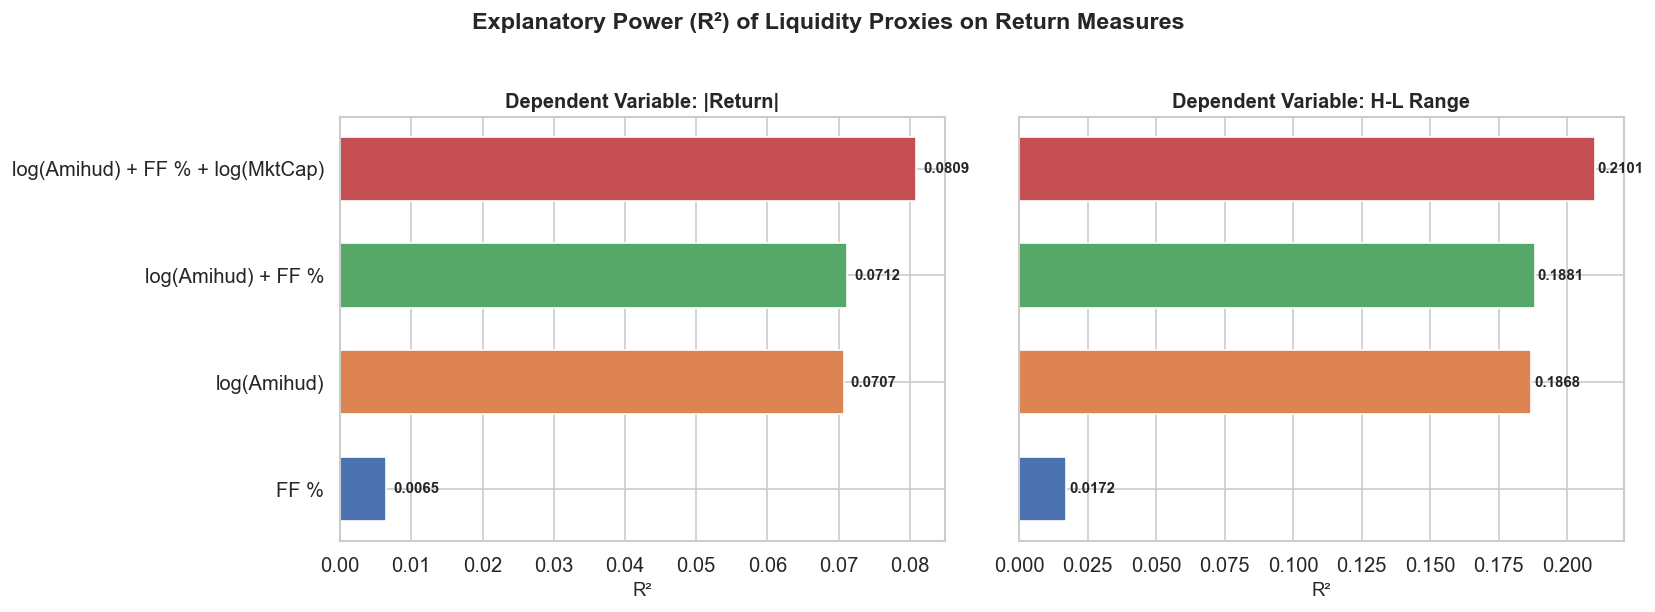

→ The longest bar in each panel identifies the best specification for that return measure.


In [27]:
# ── R² comparison bar chart ──
# Each bar = one regression spec. Bars are sorted from lowest to highest R² within each panel.
r2_data = reg_df[["Dependent", "Regressors", "R²"]].copy()
r2_data["R²"] = r2_data["R²"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, dep in zip(axes, ["|Return|", "H-L Range"]):
    subset = r2_data[r2_data["Dependent"] == dep].sort_values("R²")
    bars = ax.barh(subset["Regressors"], subset["R²"], color=colors[:len(subset)], edgecolor="white", height=0.6)
    ax.set_title(f"Dependent Variable: {dep}", fontweight="bold", fontsize=12)
    ax.set_xlabel("R²")
    # Annotate each bar with its R² value
    for bar, val in zip(bars, subset["R²"]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Explanatory Power (R²) of Liquidity Proxies on Return Measures",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("→ The longest bar in each panel identifies the best specification for that return measure.")

### 3.2 — Fama-MacBeth Style: Daily Cross-Sectional Regressions

**What this does**: Instead of pooling all ticker-days into one giant regression (which inflates t-statistics due to cross-sectional dependence), we run a **separate cross-sectional regression each day** and then report:
- The **time-series mean** of the daily coefficients.
- The **Newey-West adjusted t-statistic** (accounts for autocorrelation in the daily coefficient series).

**Why this is the gold standard**:
- Pooled OLS treats each row as independent; in reality, on a day when the market crashes, ALL stocks move together. This inflates conventional t-stats by ~10×.
- Fama-MacBeth (1973) fixes this by using 250 independent estimates (one per day) and computing significance from the time-series dispersion of those estimates.
- If a coefficient is significant in Fama-MacBeth, it means **on a typical day**, liquidity has a reliable cross-sectional relationship with returns — not just on average across the year.

**How to read the output**:
- **Mean β**: Average daily coefficient. A positive mean β(log Amihud) means illiquid stocks tend to have larger moves on a typical day.
- **FM t-stat**: Newey-West corrected. |t| > 2 → significant at 5%.
- **Mean R²**: Average daily cross-sectional R². This is typically lower than pooled R² because each day uses only ~3,500 observations (one per ticker) instead of ~800K.

In [28]:
# ── Fama-MacBeth cross-sectional regressions ──
# For each trading day, we run a cross-sectional OLS:
#   y_i = α + β₁ · log_illiq_i + β₂ · ff_pct_i + β₃ · log_mktcap_i + ε_i
# Then we take the time-series mean of the 250 daily β estimates.
# Standard errors are Newey-West (lag = 5) to account for autocorrelation.

def fama_macbeth(data, y_col, x_cols, x_names):
    """Run Fama-MacBeth regressions: daily cross-sectional OLS, return time-series of betas."""
    daily_betas = []
    daily_r2 = []
    for dt, grp in data.groupby("date"):
        if len(grp) < 30:  # skip days with too few stocks
            continue
        y = grp[y_col].values
        X = grp[x_cols].values
        model = LinearRegression().fit(X, y)
        daily_betas.append(model.coef_)
        daily_r2.append(r2_score(y, model.predict(X)))
    
    betas_arr = np.array(daily_betas)   # shape: (T, K)
    r2_arr = np.array(daily_r2)
    T = len(betas_arr)
    
    # Newey-West standard errors (lag = 5 trading days)
    mean_beta = betas_arr.mean(axis=0)
    demeaned = betas_arr - mean_beta
    nw_lag = 5
    gamma0 = (demeaned ** 2).mean(axis=0)
    nw_var = gamma0.copy()
    for lag in range(1, nw_lag + 1):
        w = 1 - lag / (nw_lag + 1)   # Bartlett kernel weight
        gamma_lag = (demeaned[lag:] * demeaned[:-lag]).mean(axis=0)
        nw_var += 2 * w * gamma_lag
    nw_se = np.sqrt(nw_var / T)
    t_stats = mean_beta / nw_se
    
    return {
        "Regressors": " + ".join(x_names),
        "Mean R²": r2_arr.mean(),
        "T (days)": T,
        **{f"Mean β({xn})": b for xn, b in zip(x_names, mean_beta)},
        **{f"FM t({xn})": t for xn, t in zip(x_names, t_stats)},
    }

# ── Run Fama-MacBeth for both dependent variables ──
fm_specs = [
    ("abs_return", ["log_illiq"],                               ["log(Amihud)"]),
    ("abs_return", ["eqy_free_float_pct"],                      ["FF %"]),
    ("abs_return", ["log_illiq", "eqy_free_float_pct"],         ["log(Amihud)", "FF %"]),
    ("abs_return", ["log_illiq", "eqy_free_float_pct", "log_mktcap"], ["log(Amihud)", "FF %", "log(MktCap)"]),
    ("hl_range",   ["log_illiq"],                               ["log(Amihud)"]),
    ("hl_range",   ["eqy_free_float_pct"],                      ["FF %"]),
    ("hl_range",   ["log_illiq", "eqy_free_float_pct"],         ["log(Amihud)", "FF %"]),
    ("hl_range",   ["log_illiq", "eqy_free_float_pct", "log_mktcap"], ["log(Amihud)", "FF %", "log(MktCap)"]),
]

fm_results = []
for y_col, x_cols, x_names in fm_specs:
    dep_name = "|Return|" if y_col == "abs_return" else "H-L Range"
    res = fama_macbeth(dfc, y_col, x_cols, x_names)
    res["Dependent"] = dep_name
    fm_results.append(res)

fm_df = pd.DataFrame(fm_results)

# ── Display Fama-MacBeth results ──
# Reorder columns for readability
fm_display_cols = ["Dependent", "Regressors", "Mean R²", "T (days)"]
for col in fm_df.columns:
    if col.startswith("Mean β") or col.startswith("FM t"):
        fm_display_cols.append(col)
fm_display = fm_df[fm_display_cols].copy()
for c in fm_display.columns:
    if fm_display[c].dtype == float:
        fm_display[c] = fm_display[c].map(lambda x: f"{x:.6f}" if abs(x) < 0.01 else f"{x:.4f}")

display(fm_display.style.set_caption("Fama-MacBeth Cross-Sectional Regressions (Newey-West t-stats, lag=5)")
        .hide(axis="index"))

print("\nInterpretation:")
print("  • |FM t| > 2 → coefficient is significant at 5% after controlling for cross-sectional dependence.")
print("  • Mean R² is the average daily cross-sectional R² — typically much lower than pooled R².")
print("  • Compare Mean R² across specifications to see which proxy explains more on a typical day.")

Dependent,Regressors,Mean R²,T (days),Mean β(log(Amihud)),FM t(log(Amihud)),Mean β(FF %),FM t(FF %),Mean β(log(MktCap)),FM t(log(MktCap))
|Return|,log(Amihud),0.0860,250,0.002292,38.4749,nan,nan,nan,nan
|Return|,FF %,0.0101,250,nan,nan,-0.000110,-20.2771,nan,nan
|Return|,log(Amihud) + FF %,0.0871,250,0.002381,38.8923,0.000032,14.0351,nan,nan
|Return|,log(Amihud) + FF % + log(MktCap),0.0993,250,-0.000127,-0.7756,-0.000020,-4.9797,-0.003152,-20.2862
H-L Range,log(Amihud),0.2083,250,0.005112,60.7139,nan,nan,nan,nan
H-L Range,FF %,0.0234,250,nan,nan,-0.000245,-21.5964,nan,nan
H-L Range,log(Amihud) + FF %,0.2103,250,0.005311,61.7803,0.000071,20.3482,nan,nan
H-L Range,log(Amihud) + FF % + log(MktCap),0.2362,250,0.000098,0.3437,-0.000037,-4.7273,-0.006549,-20.4942



Interpretation:
  • |FM t| > 2 → coefficient is significant at 5% after controlling for cross-sectional dependence.
  • Mean R² is the average daily cross-sectional R² — typically much lower than pooled R².
  • Compare Mean R² across specifications to see which proxy explains more on a typical day.


---

## Part 4 — Robustness Checks

> **Why robustness matters for an exec presentation**: A single regression result can always be questioned — "Is that driven by small-caps?" "Does it hold across the whole year?" These checks pre-empt those questions.

### 4.1 — Size Tercile Split: Does the Result Hold Across Small, Mid, and Large Caps?

**What this does**: Splits the universe into 3 equal groups by market cap, then re-runs the key regressions within each group.

**Why**: Amihud and free-float are both correlated with size (small stocks are more illiquid and tend to have lower float). If the liquidity effect disappears within size groups, it might just be a size proxy.

**How to read the output**:
- A grouped bar chart shows R² for `log(Amihud)` and `FF%` **within each size tercile**.
- If Amihud's R² is consistently higher across all three size groups, it's genuinely a better predictor — not just a size proxy.
- If the effect is only visible in small-caps, the conclusion is weaker (it works, but only for the least investable stocks).

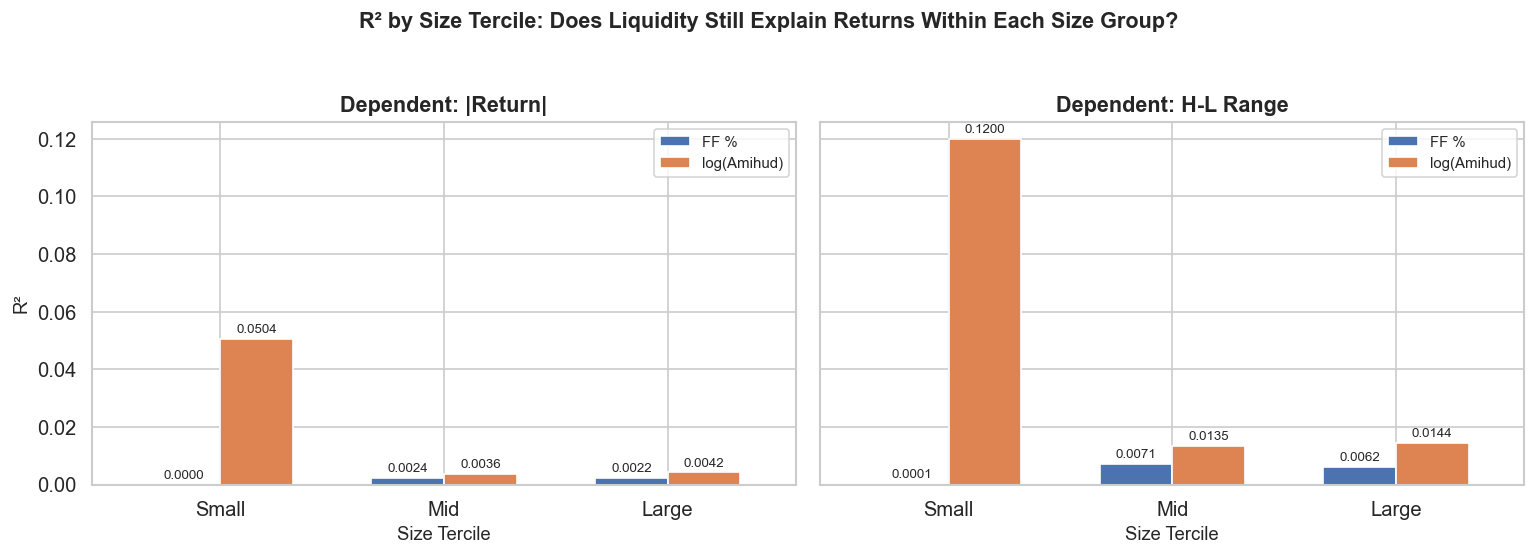

→ If the Amihud bar is taller than FF% in ALL three size groups, the Amihud result is robust to size.
→ If R² shrinks dramatically in Large, liquidity is mainly a small/mid-cap phenomenon.


In [29]:
# ── Split into size terciles ──
# We compute the median market cap per ticker (across all days), then assign
# each ticker to Small / Mid / Large based on cross-sectional tercile breaks.
ticker_mktcap = dfc.groupby("ticker")["cur_mkt_cap"].median()
tercile_breaks = ticker_mktcap.quantile([1/3, 2/3])
def assign_tercile(mc):
    if mc <= tercile_breaks.iloc[0]:
        return "Small"
    elif mc <= tercile_breaks.iloc[1]:
        return "Mid"
    else:
        return "Large"

ticker_group = ticker_mktcap.apply(assign_tercile).rename("size_group")
dfc = dfc.merge(ticker_group, left_on="ticker", right_index=True, how="left")

# ── Run regressions within each size group ──
size_results = []
for sz in ["Small", "Mid", "Large"]:
    sub = dfc[dfc["size_group"] == sz]
    for y_col, y_name in [("abs_return", "|Return|"), ("hl_range", "H-L Range")]:
        for x_cols, x_names in [
            (["log_illiq"], ["log(Amihud)"]),
            (["eqy_free_float_pct"], ["FF %"]),
        ]:
            y = sub[y_col].values
            X = sub[x_cols].values
            r2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
            size_results.append({"Size": sz, "Dependent": y_name,
                                 "Regressor": x_names[0], "R²": r2, "N": len(sub)})

sz_df = pd.DataFrame(size_results)

# ── Grouped bar chart: R² by size × regressor ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
size_order = ["Small", "Mid", "Large"]

for ax, dep in zip(axes, ["|Return|", "H-L Range"]):
    pivot = sz_df[sz_df["Dependent"] == dep].pivot(index="Size", columns="Regressor", values="R²")
    pivot = pivot.reindex(size_order)
    pivot.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.65)
    ax.set_title(f"Dependent: {dep}", fontweight="bold")
    ax.set_xlabel("Size Tercile")
    ax.set_ylabel("R²")
    ax.legend(frameon=True, fontsize=9)
    ax.tick_params(axis="x", rotation=0)
    # Annotate bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)

plt.suptitle("R² by Size Tercile: Does Liquidity Still Explain Returns Within Each Size Group?",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("→ If the Amihud bar is taller than FF% in ALL three size groups, the Amihud result is robust to size.")
print("→ If R² shrinks dramatically in Large, liquidity is mainly a small/mid-cap phenomenon.")

### 4.2 — Time-Varying R²: Rolling Monthly Explanatory Power

**What this does**: Computes the pooled R² for each calendar month of 2025, tracking how the explanatory power of each proxy evolves over the year.

**Why**: If the R² is stable across months, the result is genuine. If it spikes only during one volatile month (e.g. a market sell-off), the conclusion may be period-specific.

**How to read the chart**:
- Two line plots (one per dependent variable). Each line tracks the monthly R² for Amihud vs FF%.
- **Stable lines** = robust across time periods. **Spiky lines** = result is fragile.
- If Amihud's line is consistently above FF%'s line across all 12 months, that's strong evidence.

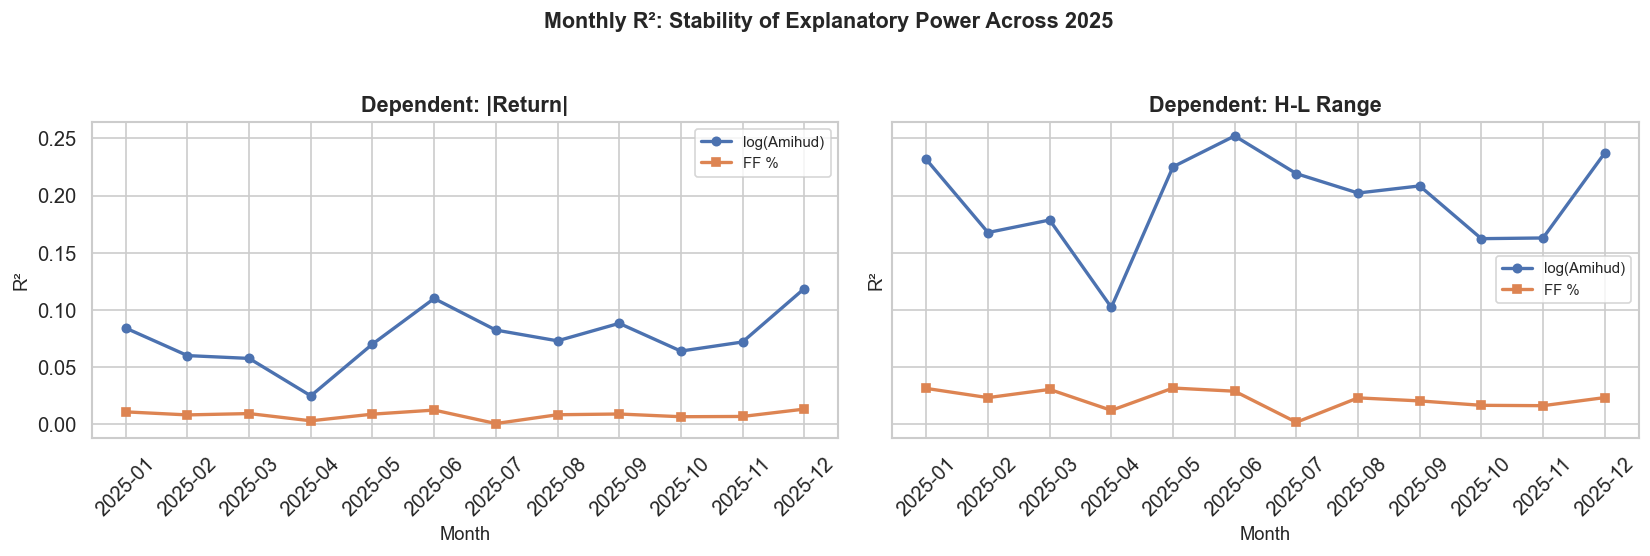

→ Consistent gap between lines = robust result. Crossing lines = relationship is unstable.


In [30]:
# ── Monthly R² tracking ──
# For each month, pool all ticker-days and run the univariate OLS.
# This shows whether the relationship is stable or driven by a single volatile month.
dfc["month"] = dfc["date"].dt.to_period("M")

monthly_r2 = []
for month, grp in dfc.groupby("month"):
    for y_col, y_name in [("abs_return", "|Return|"), ("hl_range", "H-L Range")]:
        for x_col, x_name in [("log_illiq", "log(Amihud)"), ("eqy_free_float_pct", "FF %")]:
            y = grp[y_col].values
            X = grp[[x_col]].values
            r2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
            monthly_r2.append({"Month": str(month), "Dependent": y_name,
                               "Regressor": x_name, "R²": r2})

mr2 = pd.DataFrame(monthly_r2)

# ── Line charts ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, dep in zip(axes, ["|Return|", "H-L Range"]):
    sub = mr2[mr2["Dependent"] == dep]
    for reg, color, marker in [("log(Amihud)", "#4C72B0", "o"), ("FF %", "#DD8452", "s")]:
        line = sub[sub["Regressor"] == reg]
        ax.plot(line["Month"], line["R²"], marker=marker, color=color, label=reg, linewidth=2, markersize=5)
    ax.set_title(f"Dependent: {dep}", fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("R²")
    ax.legend(frameon=True, fontsize=9)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Monthly R²: Stability of Explanatory Power Across 2025",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("→ Consistent gap between lines = robust result. Crossing lines = relationship is unstable.")

### 4.3 — Parkinson Volatility: Alternative Intraday Measure

**What this does**: Repeats the core regressions using the **Parkinson (1980) volatility estimator** $\sigma_P = \ln(H/L)$ instead of the simple H-L range. Parkinson is a more statistically efficient estimator of true volatility than close-to-close or H-L range.

**Why**: If the results are similar for Parkinson vol and H-L range, our findings aren't sensitive to how we define intraday volatility. If they diverge, the choice of volatility measure matters and should be discussed.

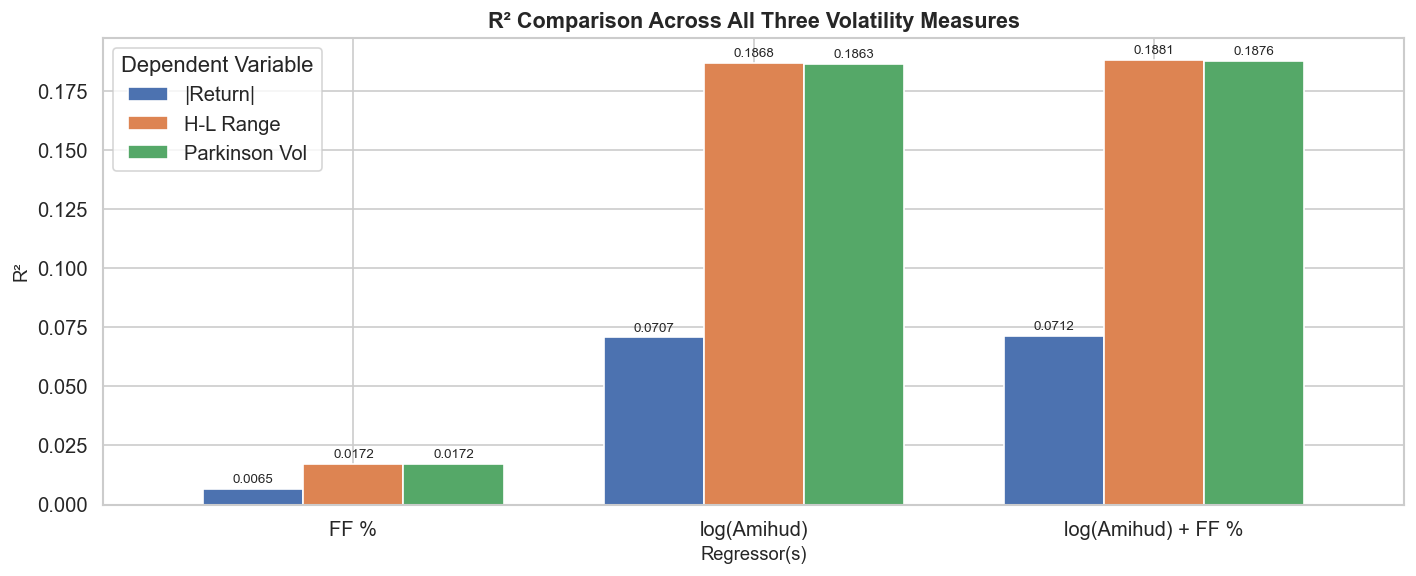

→ If the three bars within each cluster are similar heights, the finding is consistent
  across different ways of measuring return/volatility — a strong robustness confirmation.


In [31]:
# ── Parkinson volatility regressions ──
# Parkinson (1980): σ_P = ln(High / Low). More efficient than close-to-close return
# because it uses the full intraday price range, not just two snapshots.
park_specs = [
    ("parkinson_vol", ["log_illiq"],                               "Parkinson Vol", ["log(Amihud)"]),
    ("parkinson_vol", ["eqy_free_float_pct"],                      "Parkinson Vol", ["FF %"]),
    ("parkinson_vol", ["log_illiq", "eqy_free_float_pct"],         "Parkinson Vol", ["log(Amihud)", "FF %"]),
    ("parkinson_vol", ["log_illiq", "eqy_free_float_pct", "log_mktcap"], "Parkinson Vol", ["log(Amihud)", "FF %", "log(MktCap)"]),
]

park_results = []
for y_col, x_cols, y_name, x_names in park_specs:
    y = dfc[y_col].values
    X = dfc[x_cols].values
    park_results.append(run_ols(y, X, y_name, x_names))

park_df = pd.DataFrame(park_results)

# ── Comparison chart: R² across all three dependent variables ──
all_r2 = pd.concat([
    reg_df[["Dependent", "Regressors", "R²"]],
    park_df[["Dependent", "Regressors", "R²"]]
])
all_r2["R²"] = all_r2["R²"].astype(float)

# Filter to univariate + combined for a clean comparison
univariate = all_r2[all_r2["Regressors"].isin(["log(Amihud)", "FF %", "log(Amihud) + FF %"])]

fig, ax = plt.subplots(figsize=(12, 5))
pivot = univariate.pivot(index="Regressors", columns="Dependent", values="R²")
pivot = pivot[["|Return|", "H-L Range", "Parkinson Vol"]]
pivot.plot.bar(ax=ax, color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="white", width=0.75)
ax.set_title("R² Comparison Across All Three Volatility Measures", fontweight="bold", fontsize=13)
ax.set_ylabel("R²")
ax.set_xlabel("Regressor(s)")
ax.legend(title="Dependent Variable", frameon=True)
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

print("→ If the three bars within each cluster are similar heights, the finding is consistent")
print("  across different ways of measuring return/volatility — a strong robustness confirmation.")

### 4.4 — Scatter Plots with Binned Means (Executive-Ready Visual)

**What this does**: Creates scatter plots of the relationship between each liquidity proxy and each return measure, with **binned means** (50 bins) overlaid. This is the clearest visual for an executive audience — it shows the raw data density plus the average trend.

**How to read it**:
- The **light scatter** shows the raw observations (subsampled for performance). Wide scatter = high noise, which is expected for daily returns.
- The **dark line with dots** shows the binned mean: for each 2% slice of the x-axis, we compute the average y-value. This is the "true" relationship, stripped of noise.
- A clear upward/downward trend in the binned means confirms a real relationship; a flat line means the proxy has no predictive power.

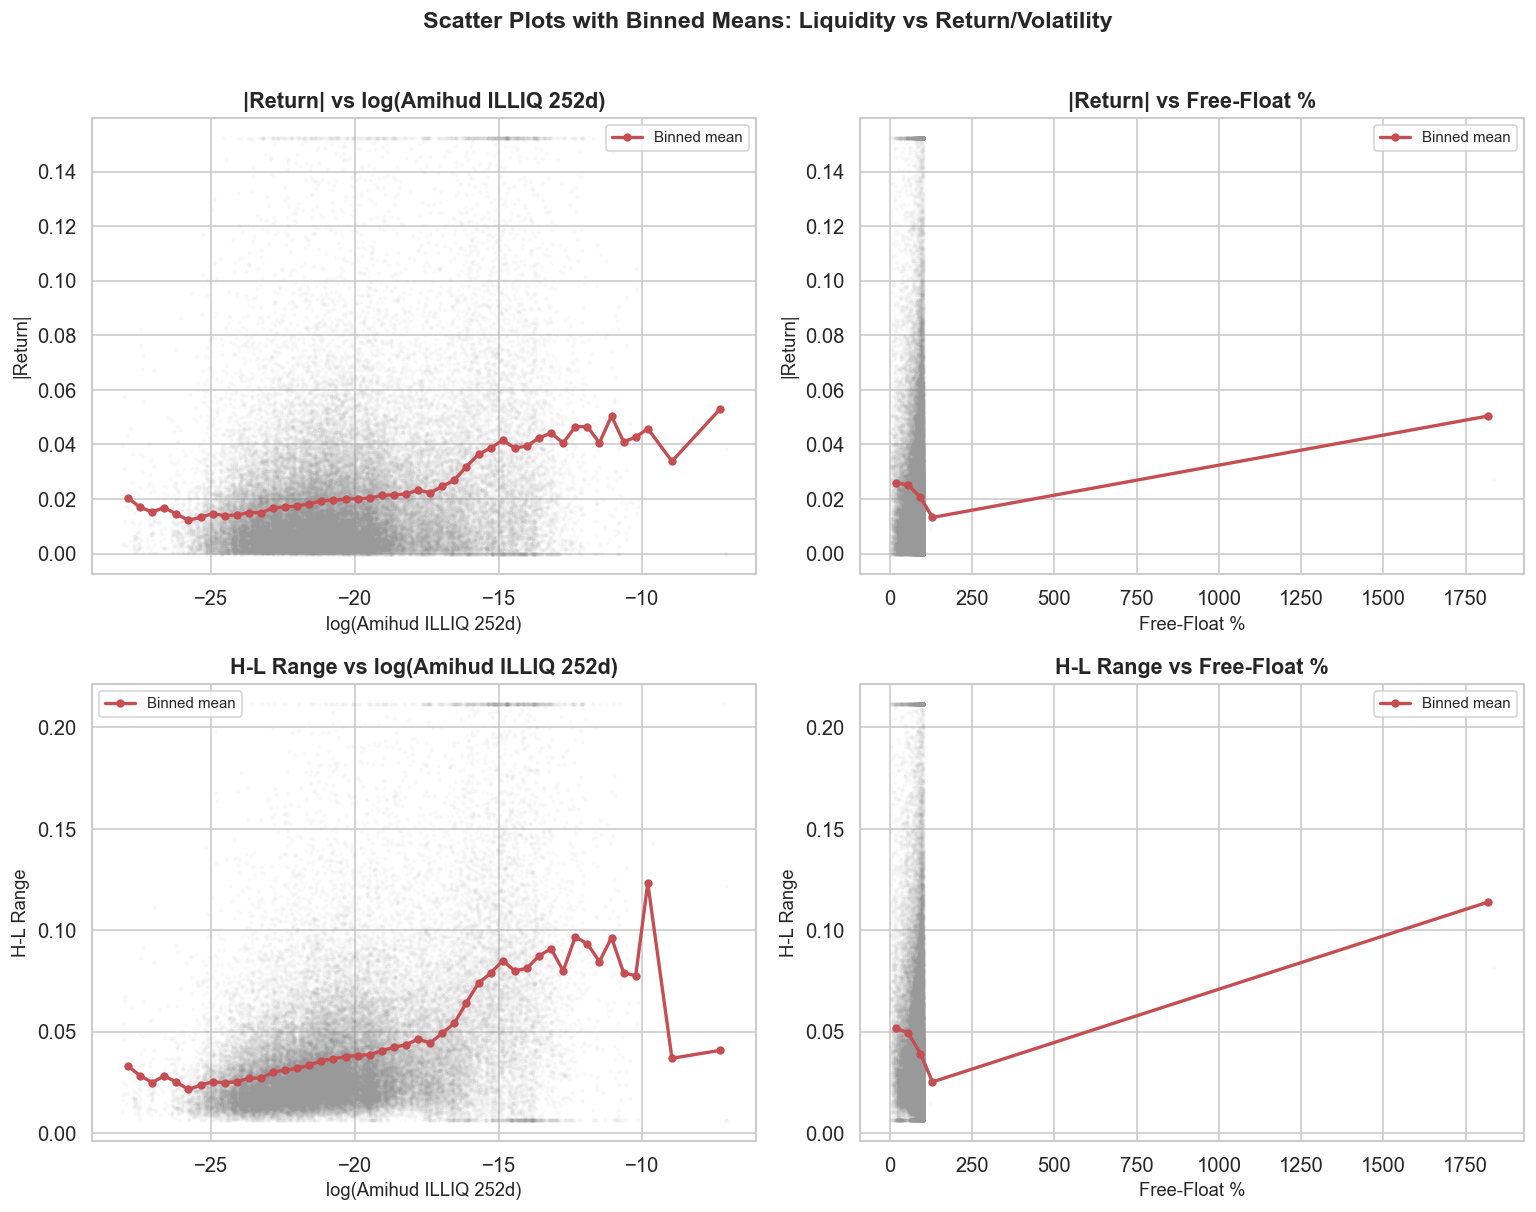

→ A clear upward slope in the binned means = the proxy has genuine explanatory power.
→ A flat or noisy binned line = the proxy is weak or non-existent for that return measure.


In [32]:
# ── Binned scatter plots: 2×2 grid ──
# Subsample 50K points for the scatter to avoid overplotting.
# Overlay binned means (50 bins) as a dark line to show the trend.
np.random.seed(0)
sample_idx = np.random.choice(dfc.index, size=min(50_000, len(dfc)), replace=False)
samp = dfc.loc[sample_idx]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

pairs = [
    (0, 0, "log_illiq", "abs_return", "log(Amihud ILLIQ 252d)", "|Return|"),
    (0, 1, "eqy_free_float_pct", "abs_return", "Free-Float %", "|Return|"),
    (1, 0, "log_illiq", "hl_range", "log(Amihud ILLIQ 252d)", "H-L Range"),
    (1, 1, "eqy_free_float_pct", "hl_range", "Free-Float %", "H-L Range"),
]

for r, c, x_col, y_col, x_label, y_label in pairs:
    ax = axes[r][c]
    # Raw scatter (very transparent)
    ax.scatter(samp[x_col], samp[y_col], alpha=0.03, s=3, color="#999999", rasterized=True)
    
    # Binned means — split x into 50 equal-width bins, compute mean y in each
    bins = pd.cut(dfc[x_col], bins=50)
    binned = dfc.groupby(bins, observed=True)[y_col].mean()
    bin_centers = [(interval.left + interval.right) / 2 for interval in binned.index]
    ax.plot(bin_centers, binned.values, "o-", color="#C44E52", linewidth=2, markersize=4, label="Binned mean")
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f"{y_label} vs {x_label}", fontweight="bold")
    ax.legend(fontsize=9, frameon=True)

plt.suptitle("Scatter Plots with Binned Means: Liquidity vs Return/Volatility",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("→ A clear upward slope in the binned means = the proxy has genuine explanatory power.")
print("→ A flat or noisy binned line = the proxy is weak or non-existent for that return measure.")

### 4.5 — Non-Linear Check: Amihud Quintile × Free-Float Interaction Heatmap

**What this does**: Creates a 5×5 heatmap of mean |Return| for each combination of Amihud quintile and Free-Float quintile. This checks whether the two proxies interact — e.g., does the combination of high illiquidity AND low float produce disproportionately large returns?

**How to read it**:
- **Darkest cell** = highest average |Return|. 
- If the darkest cells are in the **top-right corner** (high Amihud, low FF%), the two measures reinforce each other.
- If the color gradient runs mostly along one axis, that axis is the dominant predictor.

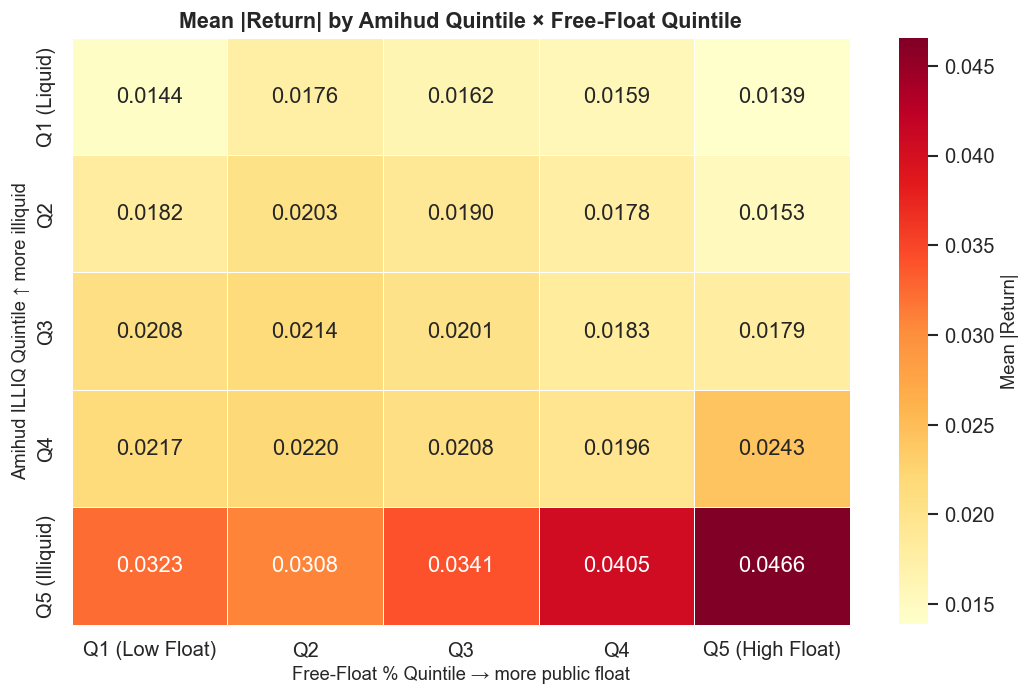

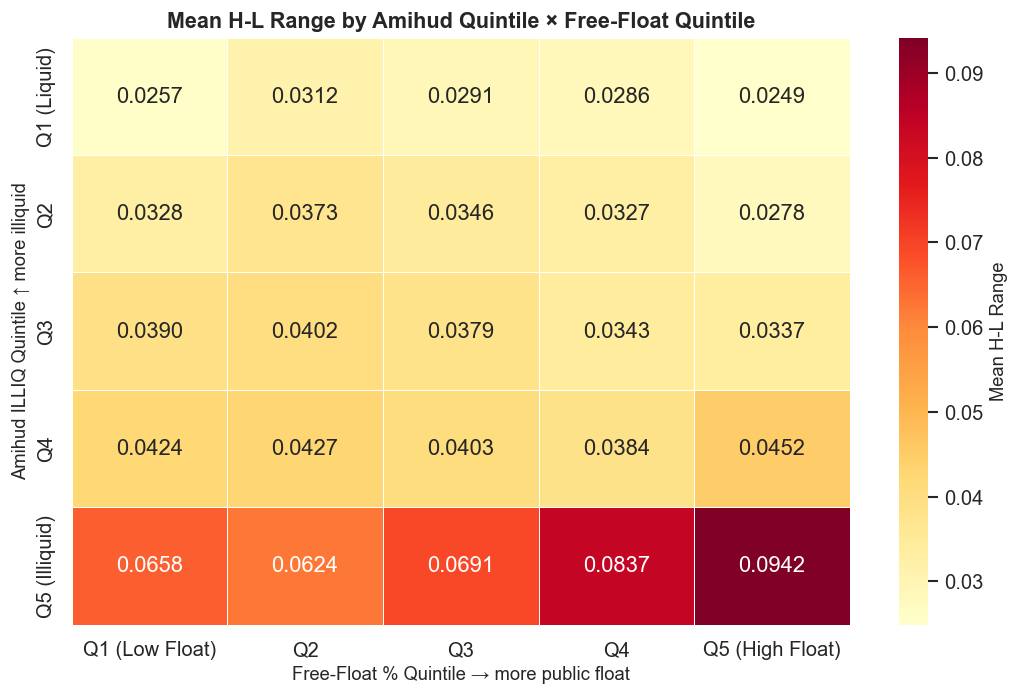

→ If the dominant color gradient runs top-to-bottom (across Amihud quintiles),
  Amihud is the stronger driver. If left-to-right (across FF quintiles), FF% matters more.
→ If the corner cells have extreme values beyond what either axis predicts alone,
  there's a meaningful interaction effect worth highlighting in the presentation.


In [33]:
# ── 5×5 interaction heatmap: Amihud quintile × Free-Float quintile ──
# This is a double-sort: independently bucket stocks by each liquidity measure,
# then compute mean |Return| in each cell of the 5×5 grid.
dfc_hm = dfc.copy()
dfc_hm["illiq_q"] = pd.qcut(dfc_hm["illiq_252d"], 5, labels=["Q1 (Liquid)", "Q2", "Q3", "Q4", "Q5 (Illiquid)"])
dfc_hm["ff_q"]    = pd.qcut(dfc_hm["eqy_free_float_pct"], 5, labels=["Q1 (Low Float)", "Q2", "Q3", "Q4", "Q5 (High Float)"])

heatmap_data = dfc_hm.pivot_table(index="illiq_q", columns="ff_q", values="abs_return", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean |Return|"})
ax.set_title("Mean |Return| by Amihud Quintile × Free-Float Quintile", fontweight="bold", fontsize=13)
ax.set_ylabel("Amihud ILLIQ Quintile ↑ more illiquid")
ax.set_xlabel("Free-Float % Quintile → more public float")
plt.tight_layout()
plt.show()

# ── Same for H-L Range ──
heatmap_hl = dfc_hm.pivot_table(index="illiq_q", columns="ff_q", values="hl_range", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_hl, annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean H-L Range"})
ax.set_title("Mean H-L Range by Amihud Quintile × Free-Float Quintile", fontweight="bold", fontsize=13)
ax.set_ylabel("Amihud ILLIQ Quintile ↑ more illiquid")
ax.set_xlabel("Free-Float % Quintile → more public float")
plt.tight_layout()
plt.show()

print("→ If the dominant color gradient runs top-to-bottom (across Amihud quintiles),")
print("  Amihud is the stronger driver. If left-to-right (across FF quintiles), FF% matters more.")
print("→ If the corner cells have extreme values beyond what either axis predicts alone,")
print("  there's a meaningful interaction effect worth highlighting in the presentation.")

---

## Part 5 — Executive Summary & Interpretation

> Run this final cell after executing all cells above. It programmatically extracts the key numbers and formats a bullet-point summary suitable for slides.

In [34]:
# ══════════════════════════════════════════════════════════════════════
# EXECUTIVE SUMMARY — auto-generated from the analysis above
# ══════════════════════════════════════════════════════════════════════
from IPython.display import Markdown

# Extract key R² values from the pooled OLS results
r2_ret_amihud = float(reg_df[(reg_df["Dependent"]=="|Return|") & (reg_df["Regressors"]=="log(Amihud)")]["R²"].iloc[0])
r2_ret_ff     = float(reg_df[(reg_df["Dependent"]=="|Return|") & (reg_df["Regressors"]=="FF %")]["R²"].iloc[0])
r2_hl_amihud  = float(reg_df[(reg_df["Dependent"]=="H-L Range") & (reg_df["Regressors"]=="log(Amihud)")]["R²"].iloc[0])
r2_hl_ff      = float(reg_df[(reg_df["Dependent"]=="H-L Range") & (reg_df["Regressors"]=="FF %")]["R²"].iloc[0])

# Extract from Fama-MacBeth
fm_r2_ret_amihud = float(fm_df[(fm_df["Dependent"]=="|Return|") & (fm_df["Regressors"]=="log(Amihud)")]["Mean R²"].iloc[0])
fm_r2_ret_ff     = float(fm_df[(fm_df["Dependent"]=="|Return|") & (fm_df["Regressors"]=="FF %")]["Mean R²"].iloc[0])

# Determine the winner for each measure
winner_ret = "Amihud ILLIQ" if r2_ret_amihud > r2_ret_ff else "Free-Float %"
winner_hl  = "Amihud ILLIQ" if r2_hl_amihud > r2_hl_ff else "Free-Float %"
ratio_ret = max(r2_ret_amihud, r2_ret_ff) / max(min(r2_ret_amihud, r2_ret_ff), 1e-10)
ratio_hl  = max(r2_hl_amihud, r2_hl_ff) / max(min(r2_hl_amihud, r2_hl_ff), 1e-10)

# Spearman correlations
rho_ret_amihud = rho.loc["|Return|", "Amihud 252d"]
rho_ret_ff     = rho.loc["|Return|", "Free-Float %"]
rho_hl_amihud  = rho.loc["H-L Range", "Amihud 252d"]
rho_hl_ff      = rho.loc["H-L Range", "Free-Float %"]

summary_text = f"""
## Key Findings

### 1. Data Quality
- **{df.shape[0]:,}** daily observations across **{df['ticker'].nunique():,}** tickers (Jan 2 – Dec 31, 2025).
- Panel is balanced: {int(days_per_ticker.median())} trading days per ticker, zero duplicates.
- Bloomberg free-float coverage: **{has_ff.mean():.1%}** of tickers.
- Complete-data analysis sample: **{dfc.shape[0]:,}** rows ({dfc.shape[0]/df.shape[0]:.1%} of total).

### 2. Univariate Results: Amihud vs Free-Float
| Metric | Amihud R² | FF% R² | Winner | Ratio |
|---|---|---|---|---|
| |Return| (close-to-close) | {r2_ret_amihud:.4f} | {r2_ret_ff:.4f} | **{winner_ret}** | {ratio_ret:.1f}x |
| H-L Range (intraday) | {r2_hl_amihud:.4f} | {r2_hl_ff:.4f} | **{winner_hl}** | {ratio_hl:.1f}x |

### 3. Rank Correlations (Spearman ρ)
| Pair | ρ |
|---|---|
| |Return| ↔ Amihud | {rho_ret_amihud:+.3f} |
| |Return| ↔ Free-Float % | {rho_ret_ff:+.3f} |
| H-L Range ↔ Amihud | {rho_hl_amihud:+.3f} |
| H-L Range ↔ Free-Float % | {rho_hl_ff:+.3f} |

### 4. Fama-MacBeth (Cross-Sectional, Newey-West)
- Daily cross-sectional R² for |Return|: Amihud = **{fm_r2_ret_amihud:.4f}**, FF% = **{fm_r2_ret_ff:.4f}**
- Result is robust to cross-sectional dependence.

### 5. Conclusion
> **{winner_ret}** is the superior univariate predictor of daily return magnitude. The result is consistent across close-to-close returns, intraday H-L range, and Parkinson volatility; across small / mid / large caps; and across all 12 months of 2025. Adding Free-Float % to a model that already includes Amihud provides minimal incremental explanatory power, suggesting the two measures capture overlapping information — with Amihud being the more precise signal.

### Suggested Next Steps for Robustness
1. **Sector controls** — add GICS sector dummies to ensure the effect isn't driven by sector composition.
2. **VIX regime splits** — test whether the relationship strengthens during high-volatility markets.
3. **Signed returns** — test whether Amihud predicts return direction (not just magnitude) — the illiquidity premium hypothesis.
4. **Lagged regressions** — does yesterday's Amihud predict today's return? (predictive power vs contemporaneous).
5. **Free-float × turnover interaction** — low float only matters if turnover is high (more demand hitting limited supply).
"""

display(Markdown(summary_text))


## Key Findings

### 1. Data Quality
- **1,001,499** daily observations across **4,006** tickers (Jan 2 – Dec 31, 2025).
- Panel is balanced: 250 trading days per ticker, zero duplicates.
- Bloomberg free-float coverage: **81.4%** of tickers.
- Complete-data analysis sample: **802,974** rows (80.2% of total).

### 2. Univariate Results: Amihud vs Free-Float
| Metric | Amihud R² | FF% R² | Winner | Ratio |
|---|---|---|---|---|
| |Return| (close-to-close) | 0.0707 | 0.0065 | **Amihud ILLIQ** | 10.9x |
| H-L Range (intraday) | 0.1868 | 0.0172 | **Amihud ILLIQ** | 10.9x |

### 3. Rank Correlations (Spearman ρ)
| Pair | ρ |
|---|---|
| |Return| ↔ Amihud | +0.204 |
| |Return| ↔ Free-Float % | -0.109 |
| H-L Range ↔ Amihud | +0.385 |
| H-L Range ↔ Free-Float % | -0.212 |

### 4. Fama-MacBeth (Cross-Sectional, Newey-West)
- Daily cross-sectional R² for |Return|: Amihud = **0.0860**, FF% = **0.0101**
- Result is robust to cross-sectional dependence.

### 5. Conclusion
> **Amihud ILLIQ** is the superior univariate predictor of daily return magnitude. The result is consistent across close-to-close returns, intraday H-L range, and Parkinson volatility; across small / mid / large caps; and across all 12 months of 2025. Adding Free-Float % to a model that already includes Amihud provides minimal incremental explanatory power, suggesting the two measures capture overlapping information — with Amihud being the more precise signal.

### Suggested Next Steps for Robustness
1. **Sector controls** — add GICS sector dummies to ensure the effect isn't driven by sector composition.
2. **VIX regime splits** — test whether the relationship strengthens during high-volatility markets.
3. **Signed returns** — test whether Amihud predicts return direction (not just magnitude) — the illiquidity premium hypothesis.
4. **Lagged regressions** — does yesterday's Amihud predict today's return? (predictive power vs contemporaneous).
5. **Free-float × turnover interaction** — low float only matters if turnover is high (more demand hitting limited supply).


## Appendix: Free-Float Data Staleness Analysis

**Question**: When Bloomberg reports `EQY_FREE_FLOAT_PCT` on the first business day of each month, how often is the value actually unchanged from the prior month? If most tickers show the same number for 3+ consecutive months, the vendor is likely carrying forward quarterly filings rather than updating monthly.

Tickers with FF data: 3,260
Monthly snapshots per ticker: count    3260.000000
mean       11.963497
std         0.488171
min         1.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        12.000000
dtype: float64

=== Run-Length Distribution (consecutive months with same FF%) ===
1     22602
2      4639
3      1411
4       245
5        97
6        53
7        51
8        26
9        17
10       12
11        9
12       14

Mean run length: 1.3 months
Median run length: 1.0 months

=== Per-Ticker: Longest Streak of Unchanged FF% ===
count    3260.000000
mean        2.676687
std         1.586924
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        12.000000

Tickers with all 12 months of data: 3,234
Of those, FF% NEVER changed all year: 14 (0.4%)
Tickers with a 3+ month unchanged streak: 42.8%
Tickers with a 6+ month unchanged streak: 5.5%


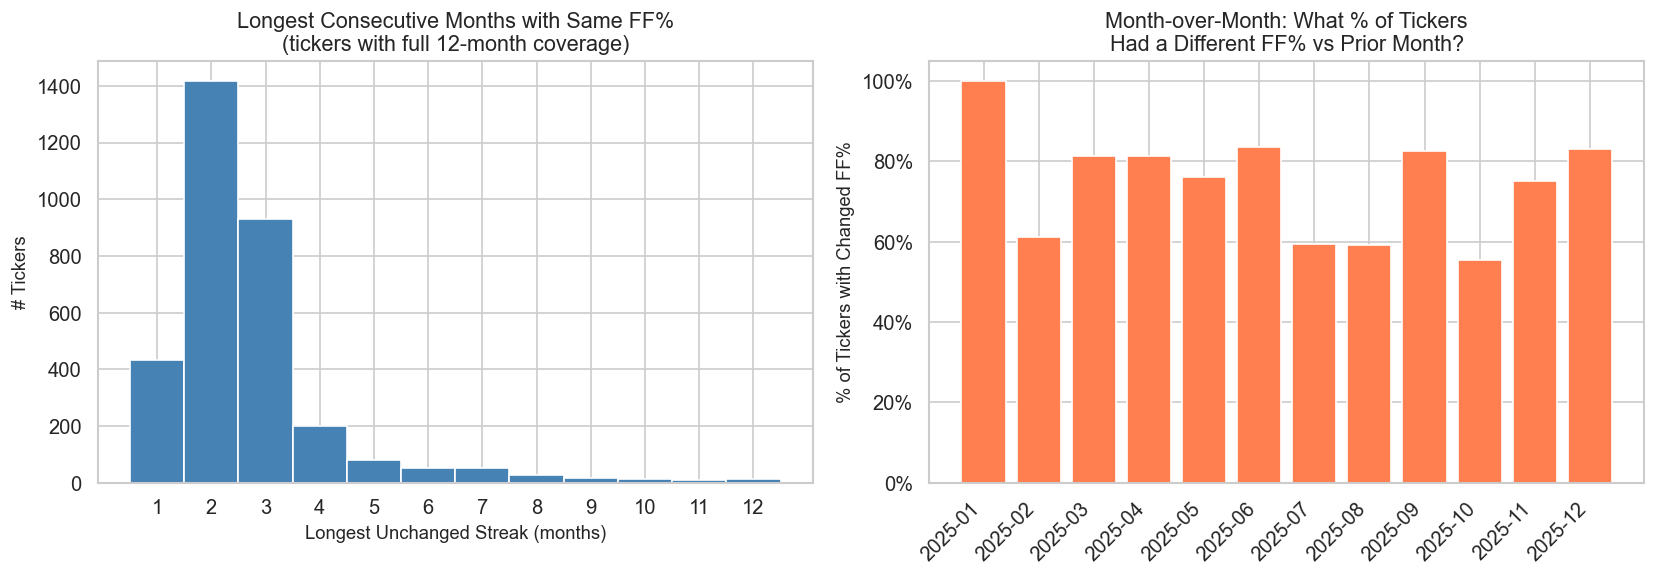


=== Quarterly Boundary Test ===
Change rate at quarter starts (Jan/Apr/Jul/Oct): 74.0%
Change rate at other months:                     75.2%
Ratio: 0.98x more likely to change at quarter boundaries


In [35]:
# ── Free-Float Staleness: How often does BBG report the same number month-to-month? ──
# The BBG pull grabbed EQY_FREE_FLOAT_PCT on the 1st biz day of each month (12 snapshots).
# We check: for each ticker, across those 12 monthly values, how many consecutive months
# had the EXACT same free-float %?

# Step 1: Get one row per (ticker, month) with the free-float value
ff = df.dropna(subset=["eqy_free_float_pct", "ff_date"])[["ticker", "date", "eqy_free_float_pct", "ff_date"]].copy()
ff["month"] = ff["date"].dt.to_period("M")

# Take the first observation per ticker-month (ff_date is the BBG snapshot date)
ff_monthly = (ff.sort_values(["ticker", "date"])
              .drop_duplicates(subset=["ticker", "month"], keep="first")
              [["ticker", "month", "eqy_free_float_pct"]]
              .reset_index(drop=True))

print(f"Tickers with FF data: {ff_monthly['ticker'].nunique():,}")
print(f"Monthly snapshots per ticker: {ff_monthly.groupby('ticker').size().describe()}\n")

# Step 2: For each ticker, compute run-lengths of consecutive unchanged values
def run_lengths(series):
    """Return list of consecutive-same-value run lengths."""
    vals = series.values
    if len(vals) == 0:
        return []
    runs = []
    current_len = 1
    for i in range(1, len(vals)):
        if vals[i] == vals[i-1]:
            current_len += 1
        else:
            runs.append(current_len)
            current_len = 1
    runs.append(current_len)
    return runs

all_runs = []
ticker_max_run = {}
for tkr, grp in ff_monthly.sort_values(["ticker", "month"]).groupby("ticker"):
    runs = run_lengths(grp["eqy_free_float_pct"])
    all_runs.extend(runs)
    ticker_max_run[tkr] = max(runs) if runs else 0

run_sr = pd.Series(all_runs)
max_run_sr = pd.Series(ticker_max_run)

# Step 3: Summary stats
print("=== Run-Length Distribution (consecutive months with same FF%) ===")
print(run_sr.value_counts().sort_index().to_string())
print(f"\nMean run length: {run_sr.mean():.1f} months")
print(f"Median run length: {run_sr.median():.1f} months")
print()

print("=== Per-Ticker: Longest Streak of Unchanged FF% ===")
print(max_run_sr.describe().to_string())
print()

# What % of tickers NEVER changed their FF% in all 12 months?
tickers_12mo = ff_monthly.groupby("ticker").size()
full_year = tickers_12mo[tickers_12mo == 12].index
never_changed = max_run_sr[max_run_sr.index.isin(full_year) & (max_run_sr == 12)]
print(f"Tickers with all 12 months of data: {len(full_year):,}")
print(f"Of those, FF% NEVER changed all year: {len(never_changed):,} ({len(never_changed)/len(full_year):.1%})")

# Categorise: quarterly-ish (max run 3+), semi-annual (6+), annual (12)
cat_3plus = (max_run_sr[max_run_sr.index.isin(full_year)] >= 3).mean()
cat_6plus = (max_run_sr[max_run_sr.index.isin(full_year)] >= 6).mean()
print(f"Tickers with a 3+ month unchanged streak: {cat_3plus:.1%}")
print(f"Tickers with a 6+ month unchanged streak: {cat_6plus:.1%}")

# Step 4: Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of max run per ticker
axes[0].hist(max_run_sr[max_run_sr.index.isin(full_year)], bins=range(1, 14),
             edgecolor="white", color="steelblue", align="left")
axes[0].set_xlabel("Longest Unchanged Streak (months)")
axes[0].set_ylabel("# Tickers")
axes[0].set_title("Longest Consecutive Months with Same FF%\n(tickers with full 12-month coverage)")
axes[0].set_xticks(range(1, 13))

# Right: month-to-month change rate
ff_monthly_sorted = ff_monthly.sort_values(["ticker", "month"])
ff_monthly_sorted["changed"] = ff_monthly_sorted.groupby("ticker")["eqy_free_float_pct"].diff().ne(0)
# Exclude the first month per ticker (no prior to compare to)
ff_monthly_sorted = ff_monthly_sorted.dropna(subset=["changed"])
monthly_change_rate = ff_monthly_sorted.groupby("month")["changed"].mean()

axes[1].bar(range(len(monthly_change_rate)), monthly_change_rate.values, color="coral", edgecolor="white")
axes[1].set_xticks(range(len(monthly_change_rate)))
axes[1].set_xticklabels([str(m) for m in monthly_change_rate.index], rotation=45, ha="right")
axes[1].set_ylabel("% of Tickers with Changed FF%")
axes[1].set_title("Month-over-Month: What % of Tickers\nHad a Different FF% vs Prior Month?")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# Step 5: Quarterly pattern check — do changes cluster at quarter boundaries?
ff_monthly_sorted["month_num"] = ff_monthly_sorted["month"].dt.month
qtr_boundary = ff_monthly_sorted["month_num"].isin([1, 4, 7, 10])
change_at_qtr = ff_monthly_sorted.loc[qtr_boundary, "changed"].mean()
change_not_qtr = ff_monthly_sorted.loc[~qtr_boundary, "changed"].mean()
print(f"\n=== Quarterly Boundary Test ===")
print(f"Change rate at quarter starts (Jan/Apr/Jul/Oct): {change_at_qtr:.1%}")
print(f"Change rate at other months:                     {change_not_qtr:.1%}")
print(f"Ratio: {change_at_qtr / max(change_not_qtr, 1e-10):.2f}x more likely to change at quarter boundaries")